# Mixture lab — observational dependence between clients

The drift sweep is an excitation experiment: each world moves **one** district and holds
everything else fixed, so stacking a network's worlds gives a design matrix with one active
column per world. This notebook turns that into two things.

1. **Per sensor** — what fraction of which district's demand change it is reading.
2. **Per district pair** — how much district *j*'s observations are contaminated by district
   *k*'s demand. That is `R[j,k]`: *a drift in k moves j's meters R times as much as an
   equivalent drift in j does*.

**Naming, because the over-claim is easy.** Each district's demand is generated independently
in the simulator. Nothing here says client *j*'s **demand** depends on client *k*'s. It says
*j*'s **observations** are contaminated by *k*'s demand — which is exactly the confound
federated training faces, and the reason a measured version of it is worth having.

**What changed in this version.** The earlier share-based matrix normalised each sensor's
responses to a simplex and gated them at `null_factor × ||Δz||`. That answered "of what this
gauge saw, what fraction came from k" — a composition, not a dependence — and the hard gate
made rows one-hot as soon as one district cleared, which is why KY7 and D-Town returned
`diag 1.000 / offdiag 0.000` while Graeme at a lower threshold returned `0.69 / 0.077`. §6
replaces it with a projection-based, soft-thresholded elasticity. The shares are kept as a
per-sensor read-out only.

## 0. Setup

In [1]:
%matplotlib inline
import sys, warnings, pathlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220, "display.max_columns", 80, "display.max_rows", 250)

HERE = pathlib.Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "conf" / "base").exists())
for p in (HERE, ROOT / "src", ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import landuse_world as lw, signal_probe as sp, landuse_sweep as ls, mixture_probe as mp

SWEEP = ROOT / "data" / "09_experiments" / "landuse_sweep"
OUT = ROOT / "data" / "09_experiments" / "mixture"
OUT.mkdir(parents=True, exist_ok=True)
print(SWEEP, SWEEP.exists())

c:\Users\arthu\USPy\10_Mestrado\fedWater\data\09_experiments\landuse_sweep True


## 1. Worlds

In [2]:
CFG = ls.SweepCfg(
    networks=("ky7", "dtown", "graeme"),
    betas=(0.0, 0.15, 0.25, 0.35, 0.40, 0.50),
    districts=None, to_land_use="industrial", to_income="low",
    n_months=44, days_per_month=14, warmup_months=2,
    max_neighbors_per_month=8, growth_chance=1.0,
    drift_ramp_days=7, seasonality_scale=0.0)

NETWORK, BETA = "ky7", 0.35
NULL_FACTOR, CORE_PURITY = 1.5, 0.85      # tiering only; §6 uses no threshold

PROBES = mp.load_cells(NETWORK, BETA, CFG, ROOT, SWEEP)
print(f"{NETWORK} @ beta={BETA}: {len(PROBES)} worlds ->", sorted(PROBES))

ky7 @ beta=0.35: 4 worlds -> ['District_A', 'District_B', 'District_C', 'District_D']


## 2. Settling

`final` cannot start at `last_switch + ramp`: the profile is still moving there. The
threshold is self-calibrating — the reproducibility ceiling is measured from the reference
months and "settled" means within a slack of it, where the slack is at least twice the spread
of those months.

,drift_district,n_months,last_switch,settle_month,settled_from,settled_months,ok,need_n_months
0,District_A,44,13,12,13,31,True,16
1,District_B,44,19,16,17,27,True,20
2,District_C,44,43,38,39,5,True,42
3,District_D,44,12,11,12,32,True,15


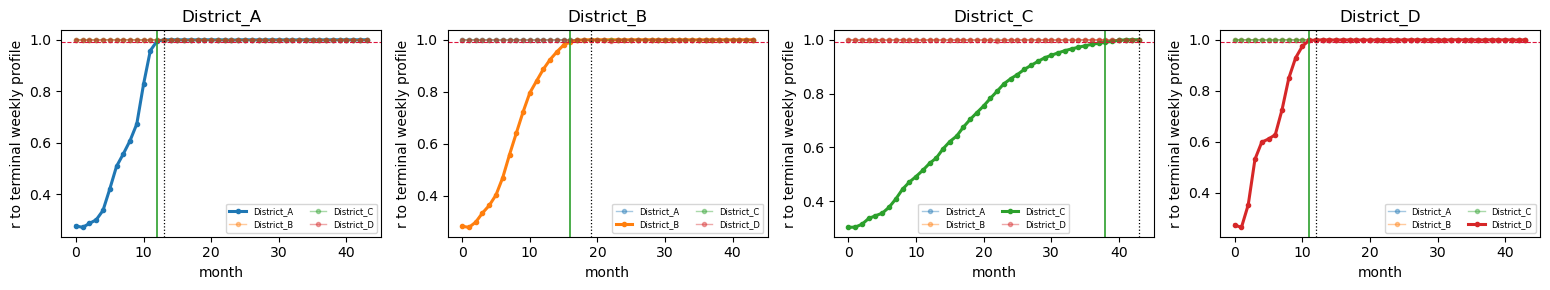

In [3]:
H = mp.horizon_check(PROBES)
display(H)
if not H["ok"].all():
    print(">>> rerun the sweep with a longer n_months before going further.")

tgts = sorted(PROBES)
fig, axes = plt.subplots(1, len(tgts), figsize=(3.9 * len(tgts), 3.0), squeeze=False)
for ax, d in zip(axes[0], tgts):
    mp.plot_settle(PROBES[d], ax=ax); ax.set_title(d)
plt.tight_layout(); plt.show()

## 3. Noise floor, and where it comes from

The split-half null is the shape wobble the world produces with nothing drifting. Its level
differs by almost 20x between networks, and that difference has driven every threshold
artefact so far — so it is worth explaining rather than absorbing.

The regression asks whether a gauge's own noise floor grows with proximity to storage:
`log10(null) ~ hops_to_storage + elevation`. Hops are unweighted shortest-path steps on the
pipe graph to the nearest tank or reservoir. Crude, but it needs no calibration. A
**negative** `b_hops` means noise falls with distance from storage, i.e. storage is the
source. A flat fit does not clear storage — it says only that this predictor does not
carry it.

In [4]:
P0 = PROBES[tgts[0]]
cand = sp.candidates(P0)
lo0, hi0 = mp.baseline_window(P0); lo1, hi1 = mp.settled_window(P0)
raw = mp.split_half_null(P0, cand)
matched = mp.split_half_null(P0, cand, windows=((lo0, hi0), (lo1, hi1)))
print(f"baseline months {lo0//P0.steps_month}..{hi0//P0.steps_month-1} | "
      f"settled months {lo1//P0.steps_month}..{hi1//P0.steps_month-1}")
print(f"null raw median {np.median(raw):.3f} | matched median {np.median(matched):.3f}")

baseline months 0..1 | settled months 13..43
null raw median 9.009 | matched median 4.648


  District_A: settled from month 13
  District_B: settled from month 17
  District_C: settled from month 39
  District_D: settled from month 12


,kind,n,r2,intercept,b_hops,b_elevation,r_hops_only,null_median,hops_median
0,pressure,463,0.2515,0.3827,0.0,0.0024,-0.1107,5.3532,11.0


,kind,n,r2,intercept,b_hops,b_log10_mean_flow,r_hops_only,null_median,hops_median
0,flow,604,0.1451,0.7197,-0.0158,0.1156,-0.2642,4.8464,10.0


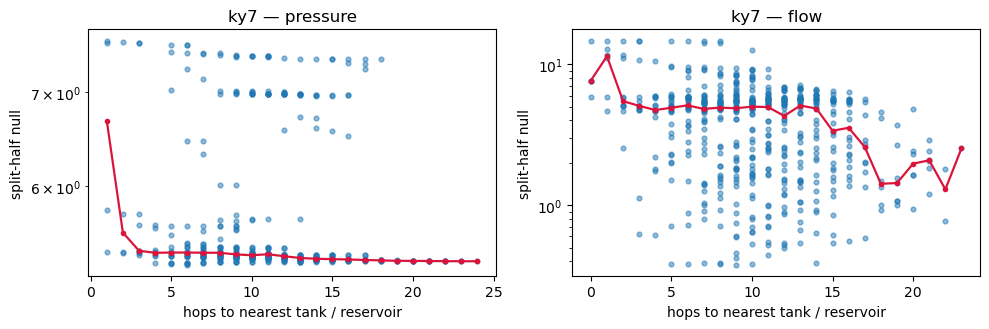

In [5]:
RES = mp.build_mixture(PROBES, null_factor=NULL_FACTOR, core_purity=CORE_PURITY)

NS = {k: mp.null_vs_storage(P0, RES, kind=k) for k in ("pressure", "flow")}
for k, r in NS.items():
    display(r["fit"] if r["fit"] is not None else r["note"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, k in zip(axes, ("pressure", "flow")):
    mp.plot_null_vs_storage(NS[k], ax=ax, label=f"{NETWORK} — {k}")
plt.tight_layout(); plt.show()

## 4. Per-sensor mixture

`n_live<=1_%` is the number to read first. If nearly every gauge cleared the gate for exactly
one district, the shares are one-hot by construction and say nothing about coupling — which
is a statement about the threshold, not the network. §6 avoids the gate entirely; these tiers
exist only to label gauges for placement.

In [6]:
display(mp.mixture_diagnostics(RES))
display(mp.tier_sensitivity(RES, factors=(0.5, 1.0, 1.5, 2.0, 3.0, 5.0)))
display(mp.purity_histogram(RES))

,kind,n,unusable_%,n_live<=1_%,n_live_mean,purity_median,snr_median,neg_mass_%
0,flow,604,9.603,33.609,2.371,1.0,2.773,59.768
1,pressure,463,7.991,0.000,2.944,1.0,1.766,100.000


,null_factor,core_purity,kind,core,transition,foreign,unusable,n_live_mean
0,0.5,0.85,flow,277,242,79,6,3.96
1,0.5,0.85,pressure,255,46,162,0,4.00
2,1.0,0.85,flow,275,238,79,12,3.36
3,1.0,0.85,pressure,258,43,162,0,3.99
4,1.5,0.85,flow,428,72,46,58,2.37
5,1.5,0.85,pressure,301,0,125,37,2.94
6,2.0,0.85,flow,408,60,44,92,2.03
7,2.0,0.85,pressure,0,0,0,463,1.86
8,3.0,0.85,flow,250,3,11,340,0.47
9,3.0,0.85,pressure,0,0,0,463,0.00


,kind,bin,n,share
0,flow,"[0.0, 0.15)",46,0.084
1,flow,"[0.15, 0.3)",5,0.009
2,flow,"[0.3, 0.5)",22,0.040
3,flow,"[0.5, 0.7)",25,0.046
4,flow,"[0.7, 0.85)",20,0.037
5,flow,"[0.85, 0.95)",26,0.048
6,flow,"[0.95, 1.001)",402,0.736
7,pressure,"[0.0, 0.15)",125,0.293
8,pressure,"[0.15, 0.3)",0,0.000
9,pressure,"[0.3, 0.5)",0,0.000


kind flow                             pressure                 
tier core foreign transition unusable     core foreign unusable
n     428      46         72       58      301     125       37

,district,kind,n,core,transition,foreign,unusable,readable_band,purity_max,purity_median,top_second
0,District_A,flow,31,31,0,0,0,0,1.0,1.000,
1,District_B,flow,117,107,4,4,2,2,1.0,1.000,
2,District_C,flow,420,274,63,27,56,51,1.0,1.000,
3,District_D,flow,36,16,5,15,0,5,1.0,0.584,District_C


,district,kind,n,core,transition,foreign,unusable,readable_band,purity_max,purity_median,top_second
0,District_A,pressure,30,5,0,0,25,0,1.0,0.0,
1,District_B,pressure,104,0,0,104,0,0,0.0,0.0,District_C
2,District_C,pressure,308,296,0,0,12,0,1.0,1.0,
3,District_D,pressure,21,0,0,21,0,0,0.0,0.0,District_C


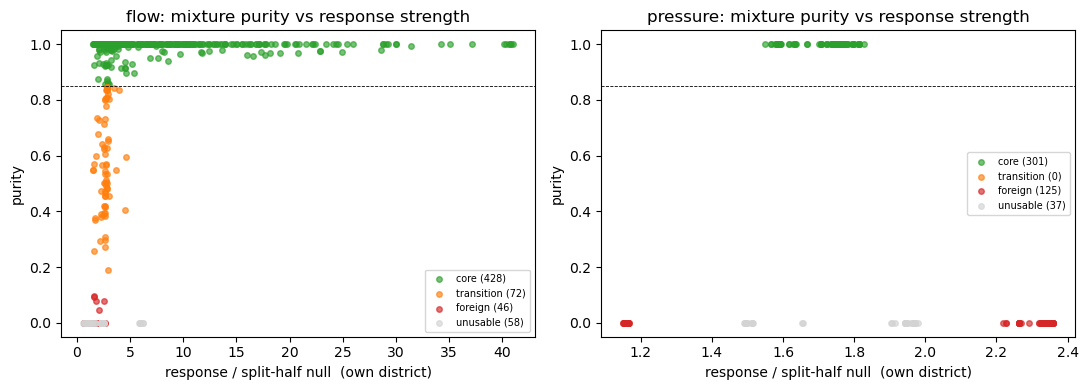

In [7]:
MIX = RES["mixture"]
display(MIX.groupby(["kind", "tier"]).size().rename("n").to_frame().T)
display(mp.zones(RES, "flow"))
display(mp.zones(RES, "pressure"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
for ax, kind in zip(axes, ("flow", "pressure")):
    mp.plot_purity(RES, kind, ax=ax)
plt.tight_layout(); plt.show()

,id,home,kind,role,tier,purity,second,w_second,snr_home,n_live,neg_mass
616,q_P-242,District_C,flow,internal,transition,0.596,District_B,0.404,4.624,3,0.032
636,q_P-260,District_C,flow,internal,transition,0.406,District_A,0.300,4.526,3,-0.000
877,q_P-485,District_C,flow,internal,transition,0.549,District_B,0.411,3.662,3,-0.000
669,q_P-291,District_C,flow,internal,transition,0.456,District_A,0.504,3.012,4,0.057
542,q_P-175,District_C,flow,internal,transition,0.654,District_B,0.344,2.968,3,-0.000
721,q_P-339,District_C,flow,internal,transition,0.188,District_B,0.793,2.959,3,-0.000
612,q_P-239,District_C,flow,internal,transition,0.660,District_B,0.339,2.955,3,-0.000
688,q_P-309,District_C,flow,internal,transition,0.845,District_B,0.155,2.875,3,0.019
733,q_P-35,District_C,flow,boundary,transition,0.838,District_B,0.162,2.868,3,0.020
848,q_P-458,District_C,flow,internal,transition,0.835,District_B,0.165,2.861,3,0.021


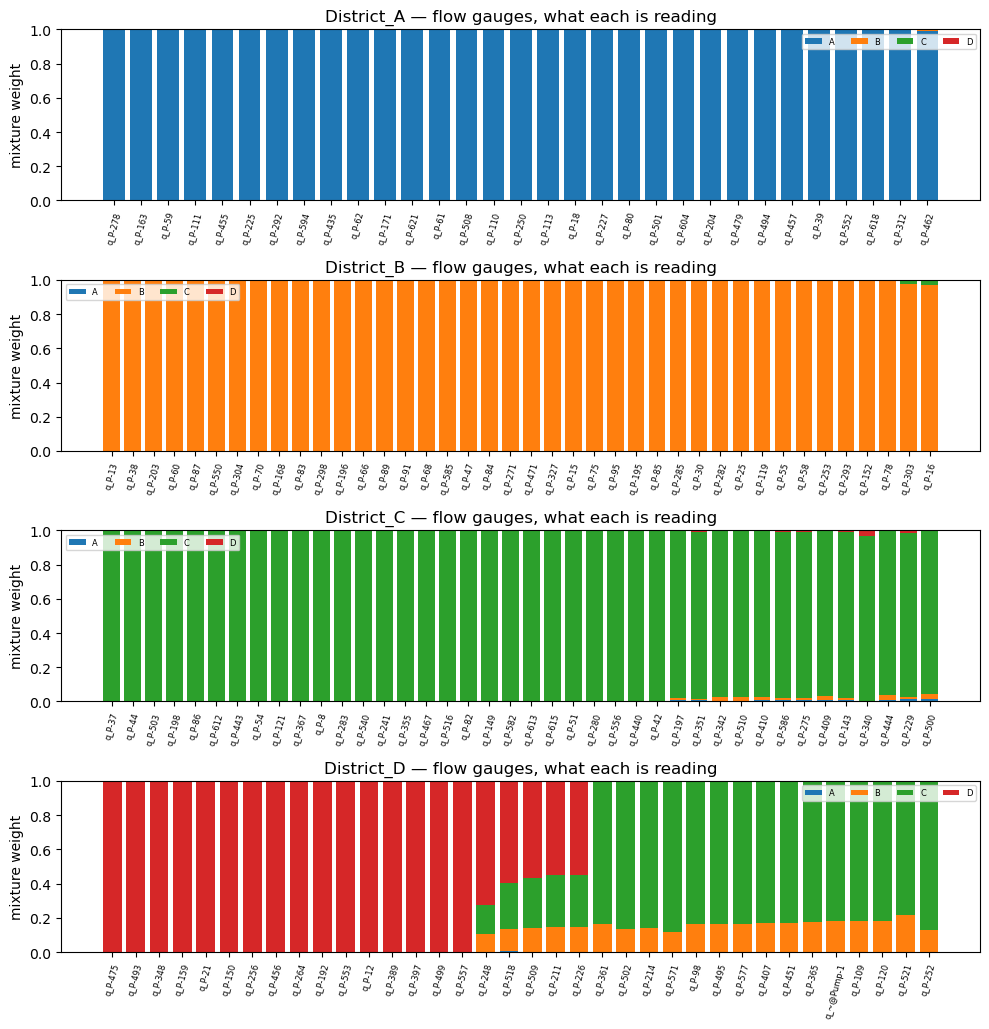

In [8]:
# The readable set: gauges carrying a quantified blend rather than a one-hot.
cols = ["id", "home", "kind", "role", "tier", "purity", "second", "w_second",
        "snr_home", "n_live", "neg_mass"]
display(MIX[(MIX["tier"] == "transition") & (MIX["w_second"] > 0.15)]
        .sort_values("snr_home", ascending=False).head(20)[cols].round(3))

fig, axes = plt.subplots(len(tgts), 1, figsize=(10, 2.6 * len(tgts)))
for ax, d in zip(np.atleast_1d(axes), tgts):
    mp.plot_mixture_bars(RES, d, "flow", top=40, ax=ax)
plt.tight_layout(); plt.show()

## 5. Dependence — the corrected estimator

Per sensor `s`, in the world where district `k` drifted:

```
u_k    = Δz_d(k) / ||Δz_d(k)||            unit direction of k's demand-shape change
P[s,k] = <Δz_s , u_k>                     the response along it
ν[s,k] = |<split-half Δz_s , u_k>|        the noise ON THE SAME DIRECTION
P̃      = sign(P)·max(|P| − ν, 0)          soft threshold — continuous, no cliff
E[s,k] = P̃[s,k] / ||Δz_d(k)||             per unit of excitation
```

`D[j,k]` is the mean `|E|` over **every** gauge homed in `j` — not the best few. Taking the
top gauges by own-district SNR selects the purest ones and drives the off-diagonal to zero by
construction, which is the circularity that made the earlier matrices look like identity.

`R = D / diag(D)` is the form to quote: diagonal 1, and the same gauges appear in numerator
and denominator so the placement confound largely cancels. `R[j,k] > 1` is meaningful and not
an error — it says j's meters respond *more* to k's drift than to j's own.

gauges per district — flow: {'District_A': 31, 'District_B': 117, 'District_C': 420, 'District_D': 36}


,District_A,District_B,District_C,District_D
District_A,0.9767,0.0029,0.0024,0.0028
District_B,0.0240,0.7422,0.0484,0.0334
District_C,0.0244,0.0733,0.4386,0.0506
District_D,0.0009,0.0222,0.1798,0.5254


,District_A,District_B,District_C,District_D
District_A,1.000,0.003,0.003,0.003
District_B,0.032,1.000,0.065,0.045
District_C,0.056,0.167,1.000,0.115
District_D,0.002,0.042,0.342,1.000


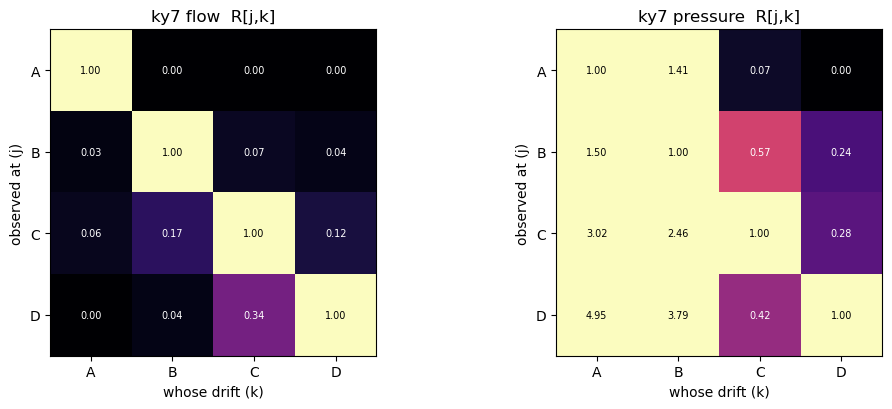

In [9]:
D_flow, R_flow, n_flow = mp.dependence(RES, kind="flow")
D_pres, R_pres, n_pres = mp.dependence(RES, kind="pressure")
print("gauges per district — flow:", n_flow.to_dict())
display(D_flow.round(4))
display(R_flow.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2))
mp.plot_matrix(R_flow, ax=axes[0], title=f"{NETWORK} flow  R[j,k]", vmax=1.0,
               xlabel="whose drift (k)", ylabel="observed at (j)")
mp.plot_matrix(R_pres, ax=axes[1], title=f"{NETWORK} pressure  R[j,k]", vmax=1.0,
               xlabel="whose drift (k)", ylabel="observed at (j)")
plt.tight_layout(); plt.show()

In [10]:
display(mp.dependence_summary(R_flow))
display(mp.asymmetry(R_flow))

,in_mean,in_max,out_mean,out_max,net,strongest_source
District_A,0.003,0.003,0.030,0.056,0.027,District_B
District_B,0.047,0.065,0.071,0.167,0.023,District_C
District_C,0.113,0.167,0.137,0.342,0.024,District_B
District_D,0.129,0.342,0.054,0.115,-0.074,District_C


,District_A,District_B,District_C,District_D
District_A,0.000,-0.029,-0.053,0.001
District_B,0.029,0.000,-0.102,0.003
District_C,0.053,0.102,0.000,-0.227
District_D,-0.001,-0.003,0.227,0.000


`in_mean` is how contaminated *j*'s meters are; `out_mean` is how far *j*'s own drift travels.
High `out` with low `in` is an upstream driver, the reverse a downstream sink. `net` is the
closest thing to a direction this design supports — it is an influence asymmetry, not a
causal one.

### Does the estimator behave as derived?

`noise_pass_rate` — share of (gauge, district) cells below their own noise floor. Near 0 means
the floor is underestimated and everything looks significant. `shrink_effect_r` — correlation
between raw and shrunk elasticities; near 1 means the result does not hinge on the soft
threshold. `diag_dominance` — share of gauges whose largest `|E|` is their own district; the
honest version of "hit rate", using no threshold and no tiering.

In [11]:
display(pd.concat([mp.estimator_checks(RES, "flow"),
                   mp.estimator_checks(RES, "pressure")], ignore_index=True))

# Sensitivity of the conclusion to the one remaining choice.
rows = []
for shrink in (True, False):
    for stat in ("mean", "median"):
        D_, R_, _ = mp.dependence(RES, "flow", shrink=shrink, stat=stat)
        A = R_.to_numpy().copy(); np.fill_diagonal(A, np.nan)
        rows.append({"shrink": shrink, "stat": stat,
                     "offdiag_mean": float(np.nanmean(A)),
                     "offdiag_max": float(np.nanmax(A))})
display(pd.DataFrame(rows).round(3))

,kind,n_gauges,noise_pass_rate,shrink_effect_r,diag_dominance,median_nu_over_proj
0,flow,604,0.2595,0.9890,0.7781,0.3963
1,pressure,463,0.0729,0.9903,0.0022,0.1549


,shrink,stat,offdiag_mean,offdiag_max
0,True,mean,0.073,0.342
1,True,median,0.057,0.326
2,False,mean,0.106,0.391
3,False,median,0.094,0.465


## 6. Response matrices

Rows are the district that **drifted**, columns where it was measured — the sweep's
`leak_matrix` layout, so the two read together. Each row is divided by its own diagonal, so an
entry is "this drift showed up at j's meters x as strongly as at its own".

The `core` / `transition` split is the point of the second and third panels: cores should be
close to diagonal by definition, and if the transition gauges are *not* far more coupled then
the tiering is not separating anything.

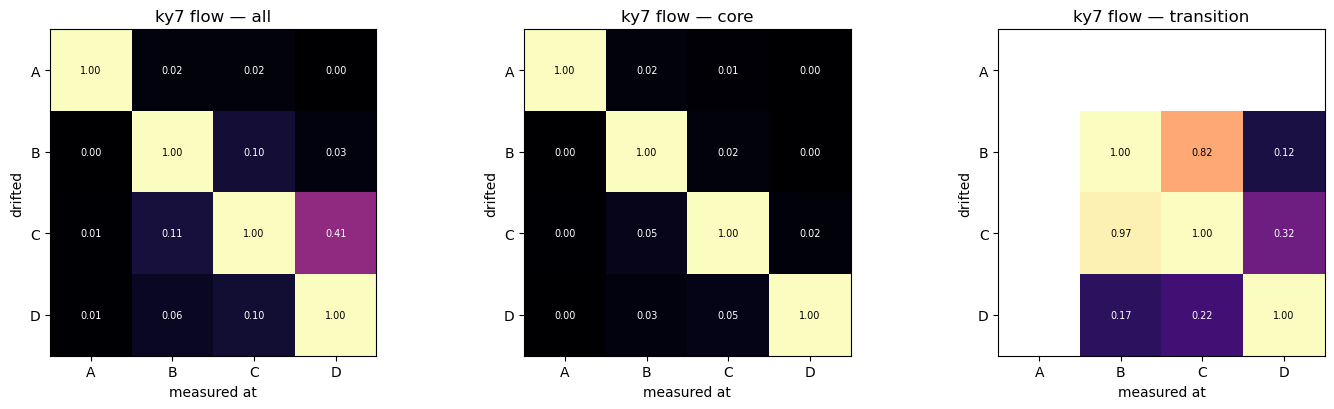

all         diagonal 1.000 | off-diagonal 0.073 | ratio 13.7x
core        diagonal 1.000 | off-diagonal 0.018 | ratio 55.9x
transition  diagonal 1.000 | off-diagonal 0.437 | ratio 2.3x


In [12]:
def response_panels(base, kind="flow", top=None):
    out = {}
    mixf = base["mixture"]
    out["all"] = mp.response_matrix(base, kind, top=top)
    for tier in ("core", "transition"):
        if (mixf["tier"] == tier).any():
            out[tier] = mp.response_matrix(base, kind, top=top, tier=tier, mixture=mixf)
    return out

PAN = response_panels(RES, "flow")
fig, axes = plt.subplots(1, len(PAN), figsize=(4.8 * len(PAN), 4.2), squeeze=False)
for ax, (name, A) in zip(axes[0], PAN.items()):
    mp.plot_matrix(A, ax=ax, title=f"{NETWORK} flow — {name}", vmax=1.0,
                   xlabel="measured at", ylabel="drifted")
plt.tight_layout(); plt.show()

for name, A in PAN.items():
    V = A.to_numpy(); off = V[~np.eye(len(V), dtype=bool)]
    print(f"{name:11s} diagonal {np.nanmean(np.diag(V)):.3f} | "
          f"off-diagonal {np.nanmean(off):.3f} | "
          f"ratio {np.nanmean(np.diag(V))/max(np.nanmean(off), 1e-9):.1f}x")

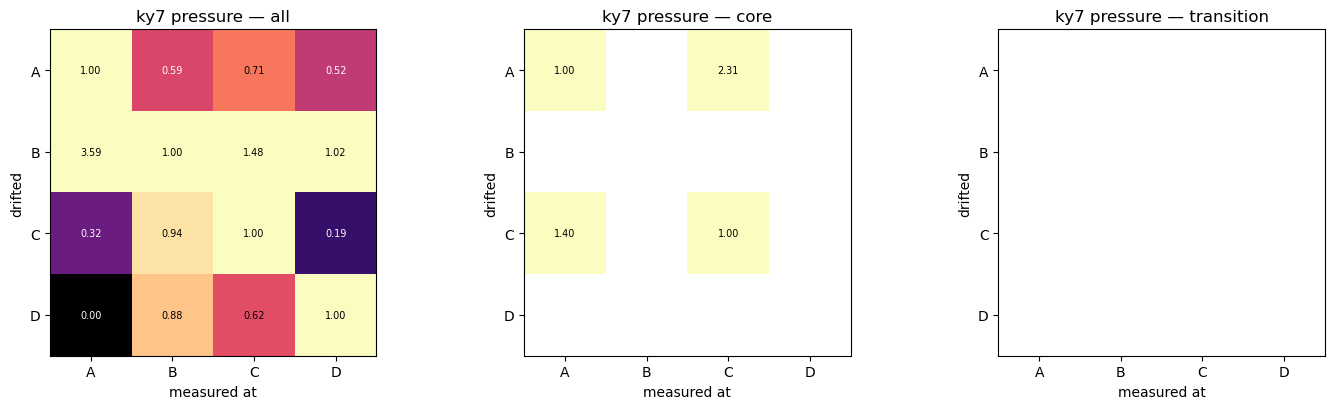

all         diagonal 1.000 | off-diagonal 0.905
core        diagonal 1.000 | off-diagonal 1.857
transition  diagonal nan | off-diagonal nan


C:\Users\arthu\AppData\Local\Temp\ipykernel_21172\4217235095.py:10: RuntimeWarning: Mean of empty slice
  print(f"{name:11s} diagonal {np.nanmean(np.diag(V)):.3f} | "
C:\Users\arthu\AppData\Local\Temp\ipykernel_21172\4217235095.py:11: RuntimeWarning: Mean of empty slice
  f"off-diagonal {np.nanmean(off):.3f}")


In [13]:
PANP = response_panels(RES, "pressure")
if PANP:
    fig, axes = plt.subplots(1, len(PANP), figsize=(4.8 * len(PANP), 4.2), squeeze=False)
    for ax, (name, A) in zip(axes[0], PANP.items()):
        mp.plot_matrix(A, ax=ax, title=f"{NETWORK} pressure — {name}", vmax=1.0,
                       xlabel="measured at", ylabel="drifted")
    plt.tight_layout(); plt.show()
    for name, A in PANP.items():
        V = A.to_numpy(); off = V[~np.eye(len(V), dtype=bool)]
        print(f"{name:11s} diagonal {np.nanmean(np.diag(V)):.3f} | "
              f"off-diagonal {np.nanmean(off):.3f}")

## 7. Contiguity of the core sets

,district,kind,n_core,components,largest_share
0,District_A,flow,31,1,1.000000
1,District_B,flow,107,1,1.000000
2,District_C,flow,274,9,0.912548
3,District_D,flow,16,2,0.684211
4,District_A,pressure,5,2,0.600000
5,District_B,pressure,0,0,NaN
6,District_C,pressure,296,2,0.996622
7,District_D,pressure,0,0,NaN


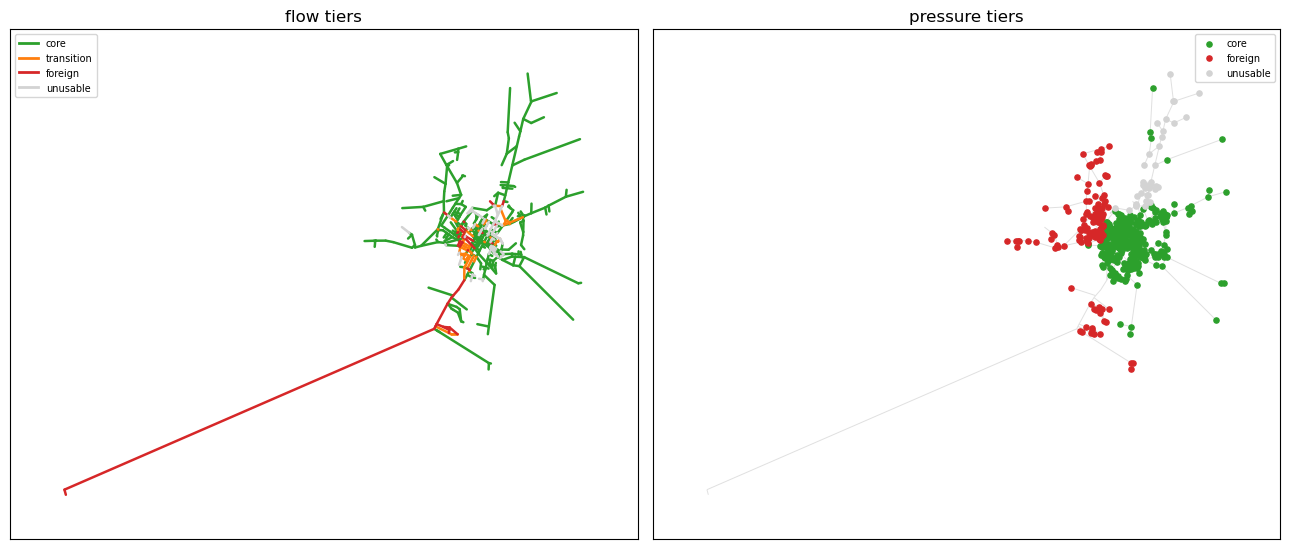

In [14]:
display(pd.concat([mp.core_connectivity(P0, RES, "flow"),
                   mp.core_connectivity(P0, RES, "pressure")], ignore_index=True))
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
mp.plot_tier_map(P0, RES, "flow", ax=axes[0])
mp.plot_tier_map(P0, RES, "pressure", ax=axes[1])
plt.tight_layout(); plt.show()

## 8. Is the response operator linear?

`E` is already per unit of excitation, so if the network responds linearly it is
beta-invariant: `r ≈ 1` and `slope ≈ 1`. The slope's distance from 1 is the size of the
non-linearity, and it decides whether a dependence matrix measured at one operating point can
be quoted at another.

In [15]:
rows, mats = [], {}
for b in CFG.betas:
    if b == BETA:
        continue
    pr = mp.load_cells(NETWORK, b, CFG, ROOT, SWEEP)
    if len(pr) != len(PROBES):
        print(f"beta={b}: {len(pr)}/{len(PROBES)} worlds, skipped"); continue
    rb = mp.build_mixture(pr, null_factor=NULL_FACTOR, core_purity=CORE_PURITY,
                          verbose=False)
    for kind in ("flow", "pressure"):
        rows.append(mp.beta_linearity(RES, rb, kind, f"beta={BETA}", f"beta={b}"))
    mats[b] = mp.dependence(rb, "flow")[1]
LIN = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
display(LIN)

if mats:
    off = {b: float(np.nanmean(np.where(np.eye(len(M), dtype=bool), np.nan,
                                        M.to_numpy())))
           for b, M in {**mats, BETA: R_flow}.items()}
    s = pd.Series(off).sort_index()
    fig, ax = plt.subplots(figsize=(5.2, 3.2))
    ax.plot(s.index, s.to_numpy(), marker="o")
    ax.set(xlabel="beta", ylabel="mean off-diagonal R",
           title=f"{NETWORK}: is dependence an operating-point statement?")
    plt.tight_layout(); plt.show()

ValueError: settled window is 2 month(s) (settle at {'District_A': 0, 'District_B': 0, 'District_C': 41, 'District_D': 0}); extend the horizon to at least 45 months, or the post-drift profile is still moving when it is measured

## 9. All networks

In [ ]:
ALL, SUMM = {}, []
for net in CFG.networks:
    pr = mp.load_cells(net, BETA, CFG, ROOT, SWEEP)
    if len(pr) < 2:
        print(f"{net}: {len(pr)} worlds, skipped"); continue
    if not mp.horizon_check(pr)["ok"].all():
        print(f"{net}: horizon too short, skipped"); continue
    r = mp.build_mixture(pr, null_factor=NULL_FACTOR, core_purity=CORE_PURITY,
                         verbose=False)
    ALL[net] = r
    for kind in ("flow", "pressure"):
        D_, R_, _ = mp.dependence(r, kind)
        A = R_.to_numpy().copy(); np.fill_diagonal(A, np.nan)
        SUMM.append({"network": net, "kind": kind,
                     "offdiag_mean": float(np.nanmean(A)),
                     "offdiag_max": float(np.nanmax(A)),
                     "diag_abs": float(np.nanmean(np.diag(D_.to_numpy()))),
                     "null_median": float(r["null"].median()),
                     "diag_dominance": float(
                         mp.estimator_checks(r, kind)["diag_dominance"].iat[0])})
display(pd.DataFrame(SUMM).round(3))

fig, axes = plt.subplots(1, len(ALL), figsize=(4.8 * len(ALL), 4.2), squeeze=False)
for ax, (net, r) in zip(axes[0], ALL.items()):
    mp.plot_matrix(mp.dependence(r, "flow")[1], ax=ax, vmax=1.0,
                   title=f"{net} flow R[j,k]", xlabel="whose drift",
                   ylabel="observed at")
plt.tight_layout(); plt.show()

## 10. Persist

In [ ]:
for net, r in ALL.items():
    d = OUT / f"{net}_beta{BETA}"; d.mkdir(parents=True, exist_ok=True)
    r["mixture"].to_parquet(d / "mixture.parquet", index=False)
    r["gains"].to_parquet(d / "gains.parquet", index=False)
    mp.elasticity(r).to_csv(d / "elasticity.csv")
    for kind in ("flow", "pressure"):
        D_, R_, _ = mp.dependence(r, kind)
        D_.to_csv(d / f"dependence_abs_{kind}.csv")
        R_.to_csv(d / f"dependence_rel_{kind}.csv")
        mp.response_matrix(r, kind, top=None).to_csv(d / f"response_{kind}.csv")
    mp.zones(r, "flow").to_csv(d / "zones_flow.csv", index=False)
    mp.mixture_diagnostics(r).to_csv(d / "diagnostics.csv", index=False)
    print(net, "->", d)
pd.DataFrame(SUMM).to_csv(OUT / f"summary_beta{BETA}.csv", index=False)

## 11. Read-out

**The dependence claim.** `R[j,k]` from §5, per network, with `dependence_summary` for the
in/out asymmetry. State it as observational dependence: *j*'s meters are contaminated by *k*'s
demand by this factor relative to *j*'s own. Do not state it as demand-level dependence — the
demands are independent by construction.

**Validity.** Three numbers gate the claim. `noise_pass_rate` well above 0 (the floor is not
underestimated), `shrink_effect_r` near 1 (the soft threshold is not driving it), and the
shrink/stat sensitivity table showing `offdiag_mean` stable across all four variants. If any
of those fails, the matrix is an artefact of the estimator.

**Transferability.** §8. `slope ≈ 1` and a flat off-diagonal across beta means the matrix is a
property of the network and can be quoted once. Otherwise every number carries its operating
point.

**Placement.** §4's zones and §7's contiguity. Cores for attribution, transition gauges for
measuring coupling, `foreign` gauges excluded outright.

**Caution on generalising.** Three networks, one partition each, one land-use contrast
(residential → industrial). The next round changes the district assignment, which will change
every number here. What should survive is the *method* — the excitation design, the projection
estimator, the noise floor and the `R` normalisation — not the specific matrices.